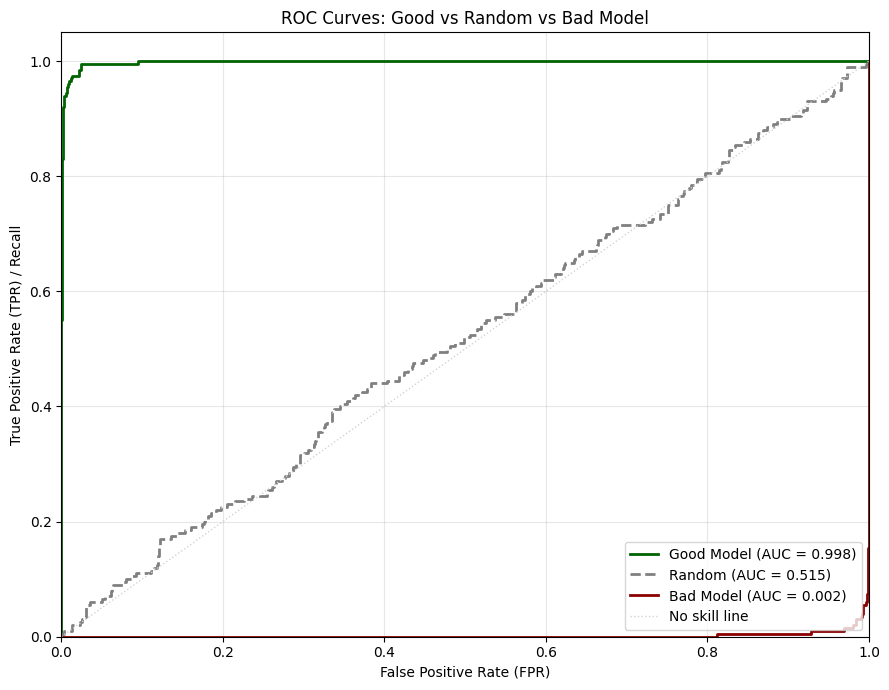

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Sun Mar 22 13:41:20 2026

@author: Administrator
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

np.random.seed(42)
n_samples = 1000

# Good model: strong separation
y_true_good = np.concatenate([np.ones(200), np.zeros(800)])
y_score_good = np.concatenate([np.random.normal(0.8, 0.15, 200),
                               np.random.normal(0.2, 0.15, 800)])

# Random model
y_true_rand = y_true_good.copy()
y_score_rand = np.random.uniform(0, 1, n_samples)

# Bad model: reverse separation
y_true_bad = y_true_good.copy()
y_score_bad = np.concatenate([np.random.normal(0.2, 0.15, 200),
                              np.random.normal(0.8, 0.15, 800)])

# Compute ROC and AUC
fpr_good, tpr_good, _ = roc_curve(y_true_good, y_score_good)
roc_auc_good = auc(fpr_good, tpr_good)

fpr_rand, tpr_rand, _ = roc_curve(y_true_rand, y_score_rand)
roc_auc_rand = auc(fpr_rand, tpr_rand)

fpr_bad, tpr_bad, _ = roc_curve(y_true_bad, y_score_bad)
roc_auc_bad = auc(fpr_bad, tpr_bad)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(fpr_good, tpr_good, color='darkgreen', lw=2,
         label=f'Good Model (AUC = {roc_auc_good:.3f})')

plt.plot(fpr_rand, tpr_rand, color='gray', lw=2, linestyle='--',
         label=f'Random (AUC = {roc_auc_rand:.3f})')

plt.plot(fpr_bad, tpr_bad, color='darkred', lw=2,
         label=f'Bad Model (AUC = {roc_auc_bad:.3f})')

plt.plot([0, 1], [0, 1], color='lightgray', lw=1, linestyle=':',
         label='No skill line')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Recall')
plt.title('ROC Curves: Good vs Random vs Bad Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()